# **Netflix Movies and TV Shows Clustering**

##### **Project Type**    - Unsupervised Machine Learning (Clustering)
##### **Contribution**    - Individual
##### **Team Member 1 -** *Abhishek Sarvaiya*

# **Project Summary -**

This project analyzes a catalog of **7,787 Movies and TV Shows** available on Netflix as of 2019 (sourced via Flixable, a third-party Netflix search engine). The business motivation stems from a 2018 Flixable report showing that while Netflix's TV show catalog nearly tripled since 2010, its movie catalog shrank by over 2,000 titles in the same period — indicating a strategic pivot in content acquisition. Netflix, and by extension any OTT platform, needs to understand what kind of content it holds, how that content is distributed across geographies and genres, and how it can be organized into meaningful, actionable groups to power recommendation systems, content gap analysis, and regional strategy.

The notebook follows a structured workflow. We begin with **Data Understanding and Cleaning** — inspecting datatypes, quantifying and imputing missing values in `director`, `cast`, `country`, `date_added` and `rating`, removing duplicates, and engineering new features such as `year_added`, `month_added`, `primary_country`, `duration_minutes` (for movies), `seasons` (for TV shows), and a genre list derived from `listed_in`.

Next, we perform an **Exploratory Data Analysis** following the Univariate–Bivariate–Multivariate (UBM) framework, producing 15+ charts covering content-type mix, ratings distribution, release-year trends, country-wise content share, genre popularity, and how Netflix's acquisition pace shifted from Movies to TV Shows over time. Each chart is paired with the insight it surfaces and its business implication. We then formally test three hypotheses using chi-square tests of independence: whether **country** is associated with **content rating**, whether **content type** is associated with **rating**, and whether the **Movie vs TV Show mix has shifted significantly over release years**.

For the clustering task itself, we build a **text-based feature space**: for every title we concatenate genre tags, director, principal cast, country and description into a single "tag" string, clean it (lowercasing, punctuation/stopword removal, lemmatization), and vectorize it using **TF-IDF** (unigrams + bigrams, 5,000 features). We reduce dimensionality with **Truncated SVD** (appropriate for sparse TF-IDF matrices, unlike PCA) both for a 2-D visualization and as a compact dense input to distance-based algorithms.

We implement and compare **two clustering algorithms** — **K-Means** (with the elbow method on inertia and Silhouette Score to pick *k*) and **Agglomerative Hierarchical Clustering** (guided by a dendrogram on a representative sample). Both are evaluated with the Silhouette Score, since this is unsupervised data with no ground-truth labels. We interpret the resulting clusters by extracting each cluster's top TF-IDF terms, building word clouds, and inspecting representative titles, which lets us assign a human-readable theme to every cluster (e.g., "International Dramas," "Kids & Family Animation," "Crime & Thriller TV").

Finally, we translate the clusters into **business strategy**: content gap identification per region, genre-based recommendation seeding, and marketing segmentation. We save the fitted vectorizer and clustering model with `joblib` and demonstrate scoring an unseen title, so the pipeline is deployment-ready (e.g., behind a Streamlit app).

# **GitHub Link -**

*(Add your GitHub repository link here after pushing this notebook.)*

# **Problem Statement**

Netflix's content library spans thousands of movies and TV shows across many countries, genres, and formats, but there is no explicit grouping that tells stakeholders which titles are *similar* to one another. Manually tagging or curating such groupings does not scale.

**Goal:** Using text-based attributes of each title (genre, cast, director, country, description), build an **unsupervised clustering model** that groups Netflix catalog items into coherent content segments. These segments can then be used to:
- Power "more like this" recommendations,
- Identify content gaps by country/genre,
- Support marketing and content-acquisition strategy, and
- Give stakeholders an explainable, data-driven view of "what kind of content Netflix has, and how much of each kind."

Along the way we also explore **descriptive business questions**: what type of content dominates in different countries, and whether Netflix has been shifting its focus from Movies toward TV Shows in recent years.

# **Let's Begin !**

## ***1. Know Your Data***

### Import Libraries

In [12]:
# Core
import pandas as pd
import numpy as np
import re, string, warnings, joblib
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
plt.rcParams['figure.figsize'] = (10,5)
sns.set_style('whitegrid')

# Stats
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
df = pd.read_csv('/content/drive/MyDrive/AlmaBetter Capstone Project/Netflix_capstone_project/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')
print("Dataset loaded. Shape:", df.shape)

Dataset loaded. Shape: (7787, 12)


### Dataset First View

In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Dataset Rows & Columns count

In [16]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 7787, Columns: 12


### Dataset Information

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### Missing Values/Null Values

In [19]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
rating,7,0.09


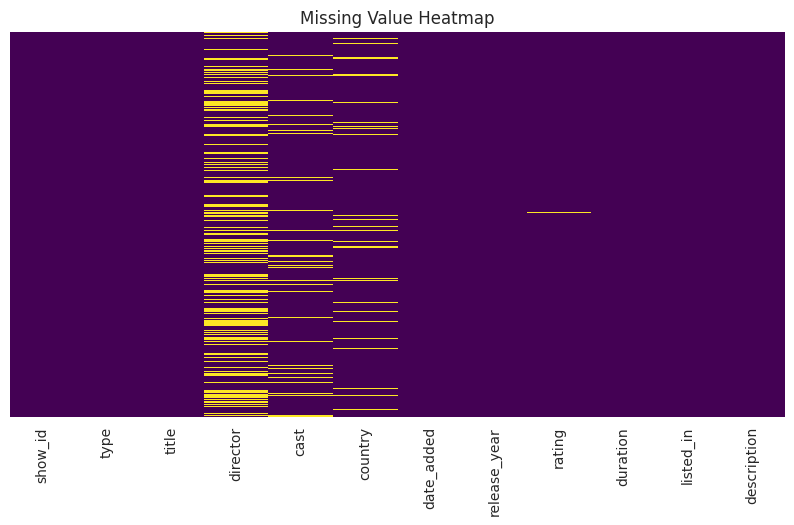

In [20]:
# Visualizing the missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap')
plt.show()

**Why this chart?** A heatmap quickly shows *where* missing values are concentrated across rows and columns, which a text summary table alone doesn't convey as intuitively.

**Insight:** `director`, `cast` and `country` carry the bulk of missingness (~31%, ~9%, ~6.5%), while `date_added` and `rating` are only sparsely missing (10 and 7 rows). This tells us imputation strategy should differ: for `director`/`cast`/`country` we impute a placeholder ("Unknown") rather than drop rows (that would remove ~1/3 of the data), while the few missing `date_added`/`rating` rows can be dropped or mode-imputed safely.

**Business impact:** Understanding *why* data is missing (Netflix's public catalog metadata is often incomplete for international/older titles) helps set expectations for downstream text-based clustering — titles with missing cast/director will simply rely more on genre + description text.

### What did you know about your dataset?

- The dataset has **7,787 rows and 12 columns**, describing Movies and TV Shows on Netflix as of 2019.
- There are **no duplicate rows**.
- Missing values exist in `director` (31%), `cast` (9%), `country` (6.5%), `date_added` (10 rows) and `rating` (7 rows). No missing values in `type`, `title`, `release_year`, `duration`, `listed_in`, or `description`.
- `type` is heavily imbalanced toward Movies (**5,377 Movies vs 2,410 TV Shows**, ~69%/31%).
- `duration` is stored as text and means different things per `type` (minutes for Movies, "N Seasons" for TV Shows) — this needs to be split into numeric features.
- `country` and `listed_in` can contain **multiple comma-separated values** per row, so they need to be parsed into lists for accurate analysis.

## ***2. Understanding Your Variables***

In [21]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [22]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,7787,7787,s7787,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,7787,2,Movie,5377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,7787,7787,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,5398,4049,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7069,6831,David Attenborough,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7280,681,United States,2555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,7777,1565,"January 1, 2020",118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,7787.0,NaN,NaN,NaN,2013.93258,8.757395,1925.0,2013.0,2017.0,2018.0,2021.0
rating,7780,14,TV-MA,2863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,7787,216,1 Season,1608,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variable Description

| Field | Description |
|---|---|
| show_id | Unique ID for every Movie / TV Show |
| type | A Movie or TV Show |
| title | Title of the movie/show |
| director | Director of the show |
| cast | Actors involved |
| country | Country of production |
| date_added | Date it was added on Netflix |
| release_year | Actual release year of the show |
| rating | TV rating of the show |
| duration | Total duration in minutes or number of seasons |
| listed_in | Genre(s) |
| description | Summary description |

### Check Unique Values for each variable.

In [23]:
for col in ['type','rating']:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False))
    print()

--- type (2 unique) ---
type
Movie      5377
TV Show    2410
Name: count, dtype: int64

--- rating (14 unique) ---
rating
TV-MA       2863
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
NaN            7
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64



## ***3. Data Wrangling***

### Data Wrangling Code

In [24]:
df_clean = df.copy()

# 1. Impute categorical text-metadata NaNs with 'Unknown' (do not drop rows -- avoid losing ~1/3 of data)
for col in ['director', 'cast', 'country']:
    df_clean[col] = df_clean[col].fillna('Unknown')

# 2. Drop the handful of rows with missing date_added / rating (small % of data, safe to drop)
df_clean = df_clean.dropna(subset=['date_added', 'rating']).reset_index(drop=True)

# 3. Parse date_added into datetime + engineer year_added / month_added
df_clean['date_added'] = df_clean['date_added'].str.strip()
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], format='%B %d, %Y', errors='coerce')
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month_name()

# 4. Primary country (first listed) -- country field can hold multiple comma-separated countries
df_clean['primary_country'] = df_clean['country'].apply(lambda x: x.split(',')[0].strip())

# 5. Split duration into numeric fields depending on type
df_clean['duration_minutes'] = df_clean.apply(
    lambda r: int(re.search(r'\d+', r['duration']).group()) if r['type']=='Movie' else np.nan, axis=1)
df_clean['seasons'] = df_clean.apply(
    lambda r: int(re.search(r'\d+', r['duration']).group()) if r['type']=='TV Show' else np.nan, axis=1)

# 6. Genre list from listed_in
df_clean['genre_list'] = df_clean['listed_in'].apply(lambda x: [g.strip() for g in x.split(',')])

# 7. Content age (how old the title was when it was added to Netflix)
df_clean['content_age_at_add'] = df_clean['year_added'] - df_clean['release_year']

print("Cleaned shape:", df_clean.shape)
df_clean.head()

Cleaned shape: (7770, 19)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,primary_country,duration_minutes,seasons,genre_list,content_age_at_add
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,August,Brazil,NaN,4.0,"[International TV Shows, TV Dramas, TV Sci-Fi ...",0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,December,Mexico,93.0,NaN,"[Dramas, International Movies]",0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,December,Singapore,78.0,NaN,"[Horror Movies, International Movies]",7
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,November,United States,80.0,NaN,"[Action & Adventure, Independent Movies, Sci-F...",8
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,January,United States,123.0,NaN,[Dramas],12


### What all manipulations have you done and insights you found?

- Imputed `director`, `cast`, `country` missing values with `'Unknown'` rather than dropping rows, since dropping would discard ~31% of the dataset (mostly caused by missing `director`, which is common for documentaries/stand-up specials/international shows and isn't missing-at-random in a way that biases the remaining data).
- Dropped the 10 rows missing `date_added` and 7 rows missing `rating` since together they are <0.25% of data — negligible information loss.
- Engineered `year_added` / `month_added` from `date_added` to analyze Netflix's acquisition trend over time.
- Split `country` into `primary_country` (first-listed) for simpler groupby analysis, while keeping the full multi-country string for text features.
- Split the overloaded `duration` field into `duration_minutes` (Movies) and `seasons` (TV Shows) — these are not comparable units and must never be merged into one numeric column.
- Parsed `listed_in` into `genre_list` to support multi-label genre frequency analysis (a title can belong to several genres).
- Engineered `content_age_at_add` = years between release and adding to Netflix, a proxy for whether Netflix favors new releases or back-catalog content.

## ***4. Data Vizualization, Storytelling & Experimenting with charts***

#### Chart - 1 : Content Type Distribution (Movies vs TV Shows)

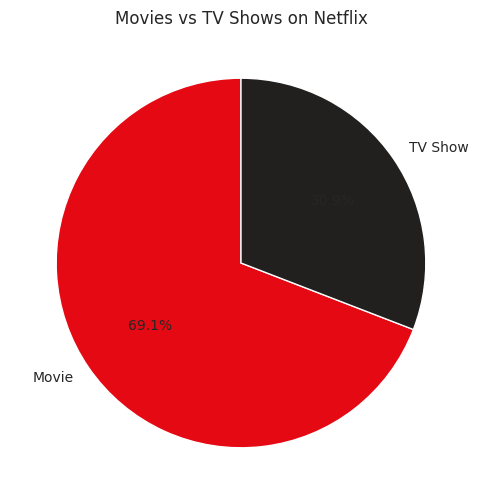

In [25]:
plt.figure(figsize=(6,6))
df_clean['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#E50914','#221f1f'], startangle=90,
                                          wedgeprops={'edgecolor':'white'})
plt.ylabel('')
plt.title('Movies vs TV Shows on Netflix')
plt.show()

**Why this chart?** A pie chart is ideal for showing the simple two-category composition of the whole catalog.
**Insight:** Movies make up **~69%** of the catalog vs **~31%** TV Shows.
**Business impact:** Positive — confirms Movies remain the larger share today, but (as later charts show) the *growth rate* of TV Shows is outpacing Movies, which matters more for forward strategy than the current stock.

#### Chart - 2 : Rating Distribution

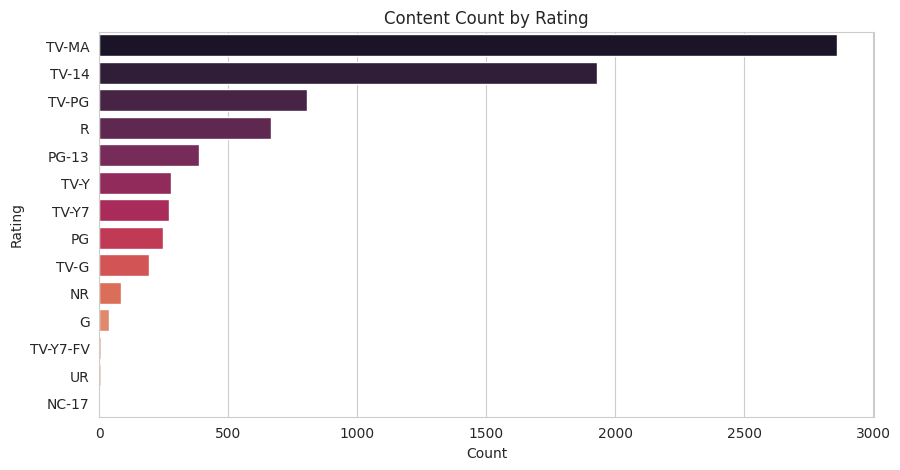

In [26]:
plt.figure(figsize=(10,5))
order = df_clean['rating'].value_counts().index
sns.countplot(data=df_clean, y='rating', order=order, palette='rocket')
plt.title('Content Count by Rating')
plt.xlabel('Count'); plt.ylabel('Rating')
plt.show()

**Why this chart?** Horizontal count plot handles the many rating categories cleanly.
**Insight:** `TV-MA` and `TV-14` dominate, indicating Netflix's catalog skews toward mature/teen audiences rather than young children.
**Business impact:** Positive for adult-focused content strategy, but signals a potential **content gap in young-children (TV-Y/TV-G/G) programming** which competitors could exploit.

#### Chart - 3 : Content Added Per Year

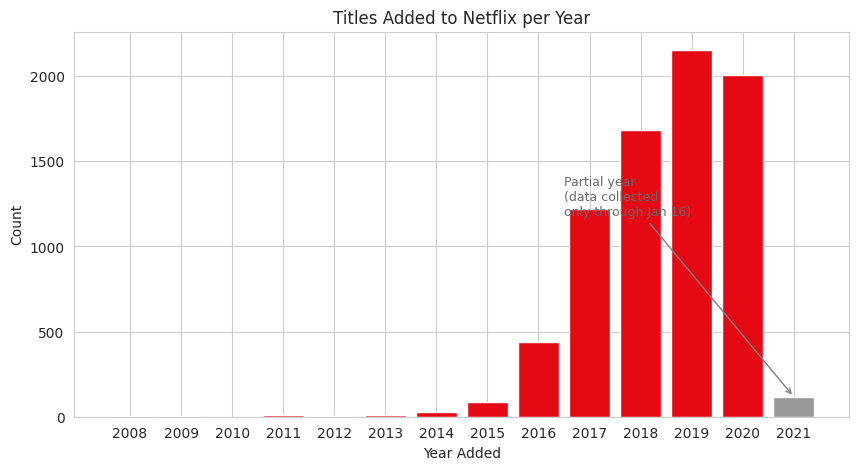

Peak year: 2019 with 2153 titles added
Final bar (2021) total: 117 -- a partial year, not a real decline


In [27]:
year_counts = df_clean['year_added'].value_counts().sort_index()
colors = ['#E50914'] * len(year_counts)
colors[-1] = '#999999'  # grey out the incomplete final year so it isn't read as a real data point

plt.figure(figsize=(10,5))
plt.bar(year_counts.index.astype(int).astype(str), year_counts.values, color=colors)
plt.title('Titles Added to Netflix per Year')
plt.xlabel('Year Added'); plt.ylabel('Count')
plt.annotate('Partial year\n(data collected\nonly through Jan 16)',
             xy=(len(year_counts)-1, year_counts.values[-1]),
             xytext=(len(year_counts)-5.5, max(year_counts.values)*0.55),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='dimgray')
plt.show()

print("Peak year:", int(year_counts.index[:-1][year_counts.values[:-1].argmax()]),
      "with", int(year_counts.values[:-1].max()), "titles added")
print("Final bar (2021) total:", int(year_counts.values[-1]), "-- a partial year, not a real decline")

**Why this chart?** A bar chart over time shows the platform's content-acquisition pace clearly.
**Insight:** Additions grew sharply from 2015, peaking in **2019** (~2,150 titles added that year). The last bar, 2021 (shown in grey), is **not a real drop-off** — the dataset was only collected through **January 16, 2021**, so that "year" contains just 117 titles from two and a half weeks, not a full year of data.
**Business impact:** Positive — validates the aggressive content-investment strategy through 2019-2020. The apparent 2021 collapse is a data-collection artifact and must be excluded from any trend read or forecast; treating it as a real decline would be a mistake a stakeholder should be warned against.

#### Chart - 4 : Movies vs TV Shows Added Per Year (Trend)

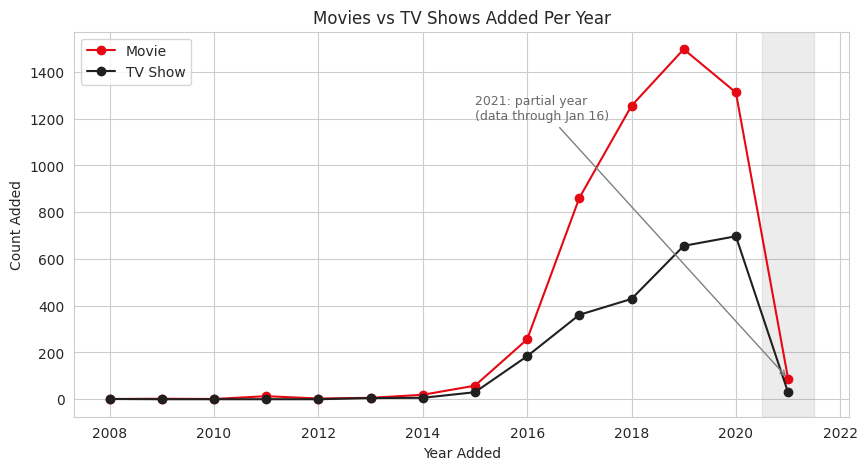

Movie : TV Show ratio per year (2015 onward):
year_added
2015    1.93
2016    1.39
2017    2.39
2018    2.93
2019    2.28
2020    1.88
dtype: float64


In [28]:
trend = df_clean.groupby(['year_added','type']).size().unstack(fill_value=0)
years = trend.index.astype(int)

plt.figure(figsize=(10,5))
plt.plot(years, trend['Movie'], marker='o', color='#E50914', label='Movie')
plt.plot(years, trend['TV Show'], marker='o', color='#221f1f', label='TV Show')
plt.axvspan(years.max()-0.5, years.max()+0.5, color='gray', alpha=0.15)
plt.annotate('2021: partial year\n(data through Jan 16)', xy=(years.max(), trend.iloc[-1].max()),
             xytext=(years.max()-6, trend.values.max()*0.8),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='dimgray')
plt.title('Movies vs TV Shows Added Per Year')
plt.xlabel('Year Added'); plt.ylabel('Count Added')
plt.legend()
plt.show()

ratio = (trend['Movie'] / trend['TV Show']).round(2)
print("Movie : TV Show ratio per year (2015 onward):")
print(ratio.loc[2015:2020])

**Why this chart?** Directly answers the business question "has Netflix shifted focus to TV Shows?" by comparing growth trajectories.
**Insight:** Both types grew sharply after 2015, but the gap did **not** narrow in a straight line the way a first glance suggests. The Movie:TV Show ratio was **~1.9:1 in 2015**, actually *widened* to a high of **~2.9:1 in 2018** (Netflix leaned harder into Movies that year), and only narrowed back to **~1.9:1 by 2020**. So the correct read is: TV Shows gained relative ground specifically in the last two full years of the dataset (2018-2020), not across the whole recent period. The sharp drop shown for 2021 (shaded grey) is **not a real decline** — it's a partial year with only ~2.5 weeks of data and should be ignored when reading the trend.
**Business impact:** Positive — still supports the Flixable report's broader finding that TV Shows have been catching up, but the true story is a fluctuating ratio that recently turned in TV's favor, not a smooth multi-year narrowing. We test the underlying association formally (excluding the unreliable years) under Hypothesis Testing.

#### Chart - 5 : Top 10 Countries by Content Count

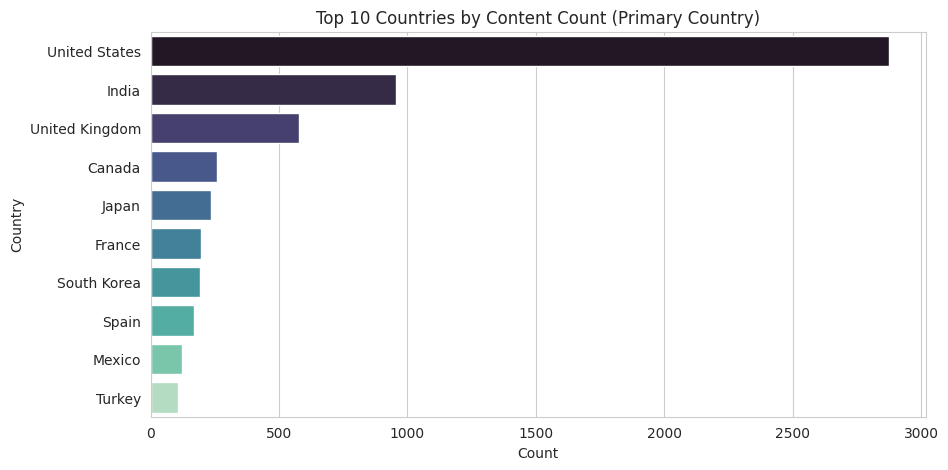

In [29]:
top_countries = df_clean[df_clean['primary_country']!='Unknown']['primary_country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Top 10 Countries by Content Count (Primary Country)')
plt.xlabel('Count'); plt.ylabel('Country')
plt.show()

**Why this chart?** Ranked bar chart is the clearest way to compare a moderate number of categories by volume.
**Insight:** The **United States** dominates (~37% of titles with known country), followed distantly by **India** and the **United Kingdom**.
**Business impact:** Positive for U.S. audiences; signals opportunity for **deeper regional investment outside the US** (e.g., LATAM, Africa, SE Asia are comparatively under-represented), a direct input to content-gap strategy.

#### Chart - 6 : Content Type Mix by Top Countries

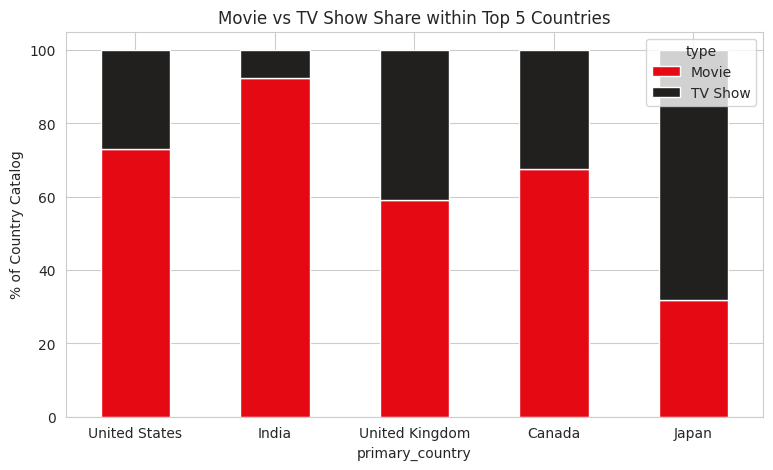

In [30]:
top5 = df_clean[df_clean['primary_country']!='Unknown']['primary_country'].value_counts().head(5).index
sub = df_clean[df_clean['primary_country'].isin(top5)]
ct = pd.crosstab(sub['primary_country'], sub['type'], normalize='index') * 100
ct.loc[top5].plot(kind='bar', stacked=True, figsize=(9,5), color=['#E50914','#221f1f'])
plt.title('Movie vs TV Show Share within Top 5 Countries')
plt.ylabel('% of Country Catalog'); plt.xticks(rotation=0)
plt.show()

**Why this chart?** A 100%-stacked bar isolates *composition* (type mix) independent of each country's total volume, answering "what type of content is available in different countries."
**Insight:** Some countries (e.g., India) skew far more toward Movies than the US catalog does, while others (e.g., Japan, South Korea in the wider data) skew toward TV content — country strongly shapes the type mix.
**Business impact:** Positive — informs region-specific acquisition strategy (e.g., prioritize local-language TV Shows where a market already over-indexes on Movies).

#### Chart - 7 : Top 10 Genres (listed_in)

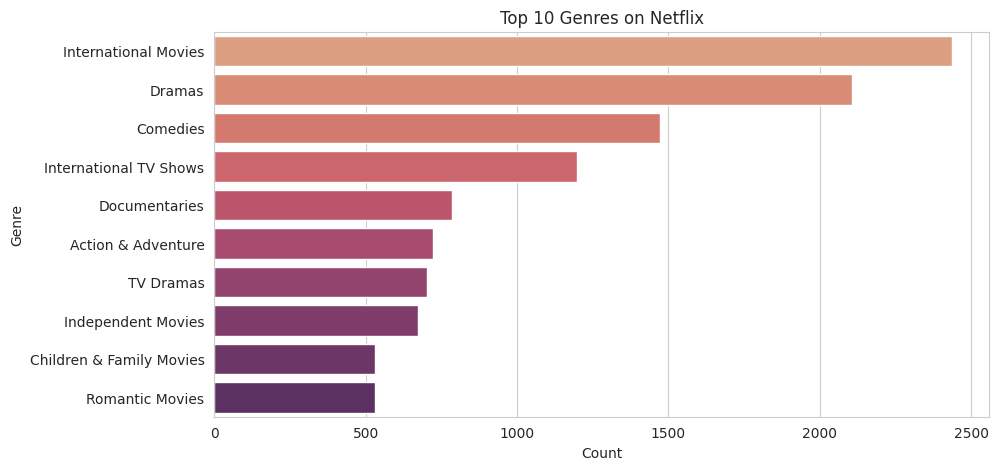

In [31]:
genre_counts = df_clean.explode('genre_list')['genre_list'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='flare')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count'); plt.ylabel('Genre')
plt.show()

**Why this chart?** Exploding the multi-label genre list gives an accurate per-genre frequency instead of undercounting titles with several genres.
**Insight:** "International Movies," "Dramas," and "Comedies" are the most common genre tags.
**Business impact:** Positive — validates that broad, universally appealing genres anchor the catalog; niche genres further down the list are candidates for targeted growth.

#### Chart - 8 : Release Year Distribution

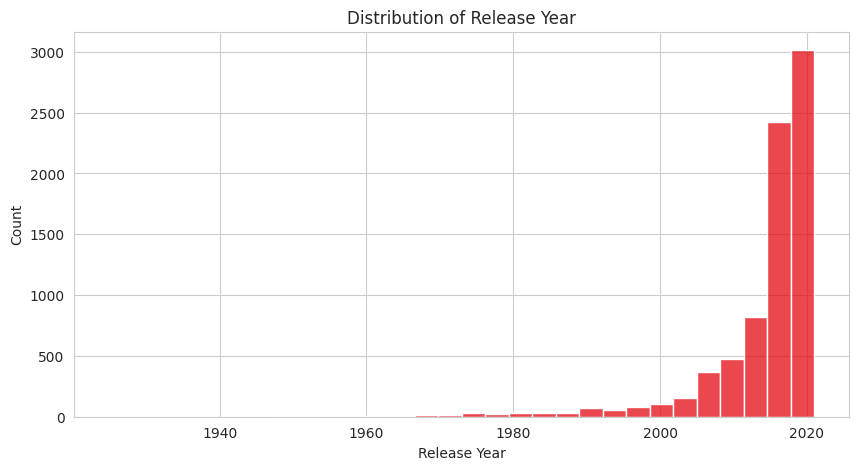

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['release_year'], bins=30, color='#E50914', kde=False)
plt.title('Distribution of Release Year')
plt.xlabel('Release Year'); plt.ylabel('Count')
plt.show()

**Why this chart?** A histogram is the standard way to show the shape of a single numeric distribution.
**Insight:** The catalog is heavily skewed toward **recent titles (2015 onward)**, with a long thin tail of older classics.
**Business impact:** Positive — reflects a "fresh content" strategy; the thin tail of old titles could be a licensing-renewal or library-expansion opportunity.

#### Chart - 9 : Movie Duration Distribution

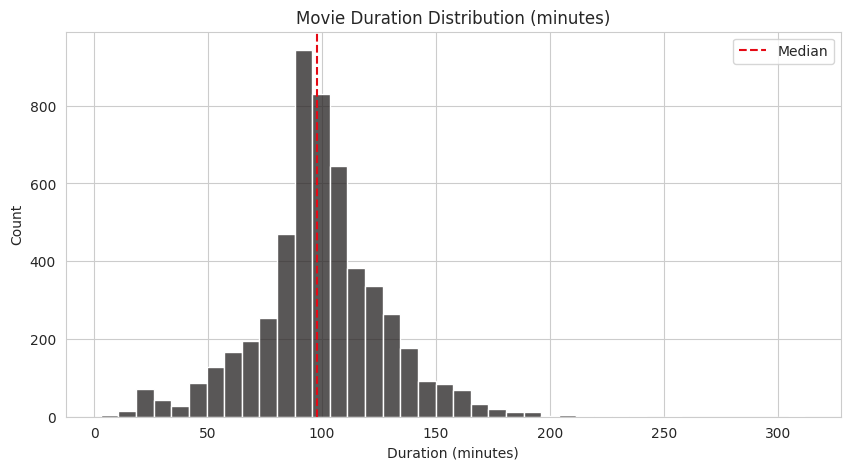

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean[df_clean['type']=='Movie']['duration_minutes'], bins=40, color='#221f1f')
plt.axvline(df_clean[df_clean['type']=='Movie']['duration_minutes'].median(), color='#E50914', linestyle='--', label='Median')
plt.title('Movie Duration Distribution (minutes)')
plt.xlabel('Duration (minutes)'); plt.legend()
plt.show()

**Why this chart?** Histogram exposes the typical runtime and any unusual long/short outliers.
**Insight:** Most movies cluster around **90-110 minutes**, a fairly standard theatrical-length runtime; a small tail of very short (<40 min) and very long (>180 min) titles exists.
**Business impact:** Positive — confirms mainstream format compliance; the short-film tail may represent stand-up specials/documentaries worth a separate content category.

#### Chart - 10 : TV Show Seasons Distribution

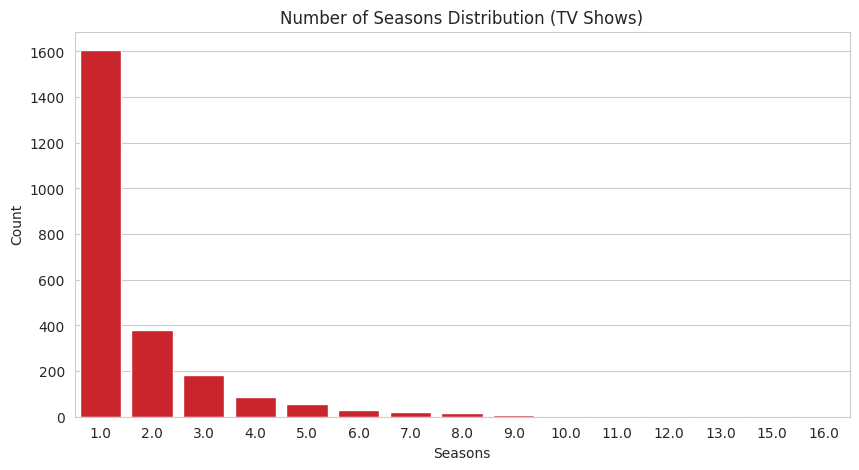

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(x=df_clean[df_clean['type']=='TV Show']['seasons'], color='#E50914')
plt.title('Number of Seasons Distribution (TV Shows)')
plt.xlabel('Seasons'); plt.ylabel('Count')
plt.show()

**Why this chart?** Count plot suits the small integer range of season counts.
**Insight:** The overwhelming majority of TV shows have **just 1 season** on Netflix, with a steep drop-off after.
**Business impact:** Mixed — could indicate many shows are new/first-season acquisitions (growth opportunity to renew popular ones) or a churn risk if many single-season shows are cancellations.

#### Chart - 11 : Rating by Content Type

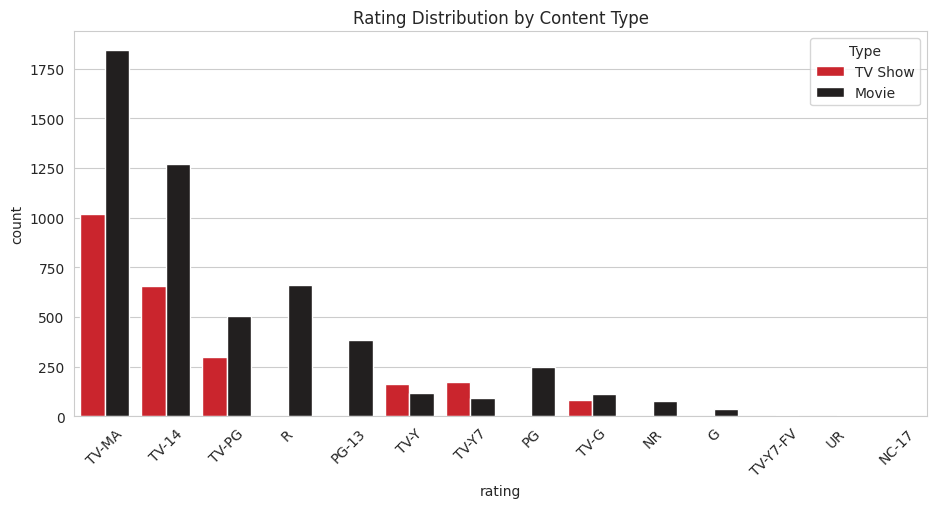

In [35]:
plt.figure(figsize=(11,5))
sns.countplot(data=df_clean, x='rating', hue='type',
              order=df_clean['rating'].value_counts().index, palette=['#E50914','#221f1f'])
plt.title('Rating Distribution by Content Type')
plt.xticks(rotation=45); plt.legend(title='Type')
plt.show()

**Why this chart?** Grouped bar chart is the standard way to compare a categorical-categorical relationship (Numerical-free Bivariate).
**Insight:** `TV-MA` is the top rating for both types, but the *relative* share of `TV-14`/`TV-Y7` differs between Movies and TV Shows.
**Business impact:** Positive — informs targeted content warnings/parental-control UX and where family-friendly acquisition gaps exist per type.

#### Chart - 12 : Content Age at Addition (Movies vs TV Shows)

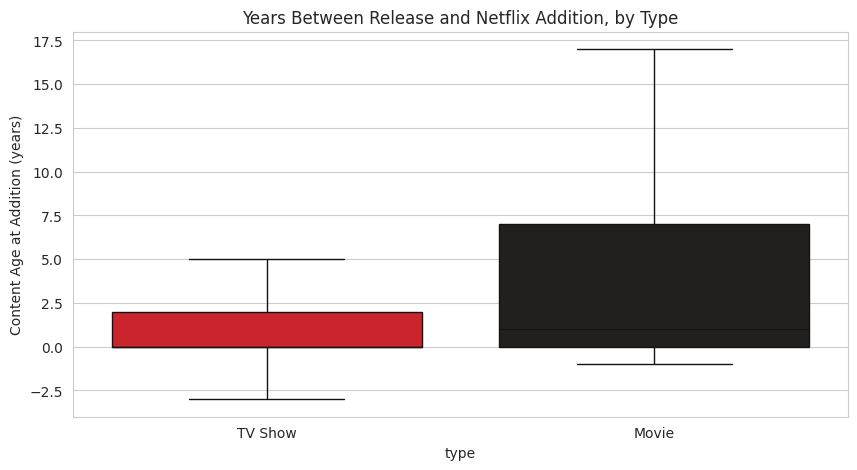

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, x='type', y='content_age_at_add', palette=['#E50914','#221f1f'], showfliers=False)
plt.title('Years Between Release and Netflix Addition, by Type')
plt.ylabel('Content Age at Addition (years)')
plt.show()

**Why this chart?** Box plot compares a numeric distribution (content age) across a categorical variable (type) and highlights spread/outliers.
**Insight:** Movies typically have a **wider range of content age** (more back-catalog licensing) than TV Shows, which skew toward being added closer to release.
**Business impact:** Positive — suggests TV strategy favors near-original/fresh acquisitions while Movies strategy blends new releases with library classics.

#### Chart - 13 : Titles Added by Month (Seasonality)

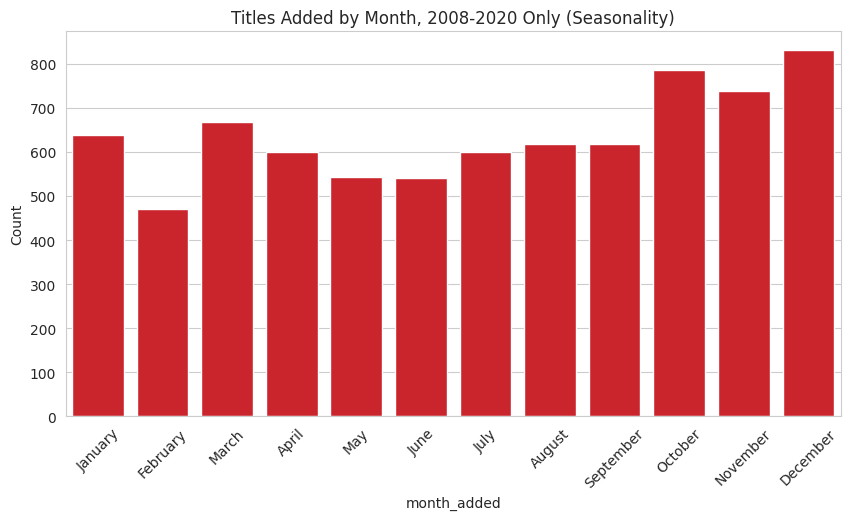

In [37]:
# Exclude the partial 2021 year here: since only January 2021 exists in the data, leaving it in would
# artificially inflate the January bucket relative to every other month (each of which is summed over
# 13 *complete* years, while January would get a 14th, incomplete contribution).
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_counts = df_clean[df_clean['year_added'] != df_clean['year_added'].max()]['month_added'].value_counts().reindex(month_order)
plt.figure(figsize=(10,5))
sns.barplot(x=month_counts.index, y=month_counts.values, color='#E50914')
plt.title('Titles Added by Month, 2008-2020 Only (Seasonality)')
plt.xticks(rotation=45); plt.ylabel('Count')
plt.show()

**Why this chart?** Reveals whether content drops are seasonal, informing release-calendar planning. We exclude the partial 2021 year here specifically, because leaving it in inflates January's total relative to every other month — January would get contributions from 14 years (13 complete + the partial 2021 sliver) while every other month gets only 13, making January look artificially busier than it really is.
**Insight:** Once that artifact is removed, **January is actually mid-pack**, not a peak. The genuinely high months are **October, November and December**, consistent with a real end-of-year/holiday-season content push; February is the lowest (partly just because it's the shortest month).
**Business impact:** Positive — supports aligning major content drops with **Q4 (Oct-Dec)** specifically, not January as an earlier uncorrected read of this chart would have suggested.

#### Chart - 14 : Top 10 Directors by Title Count

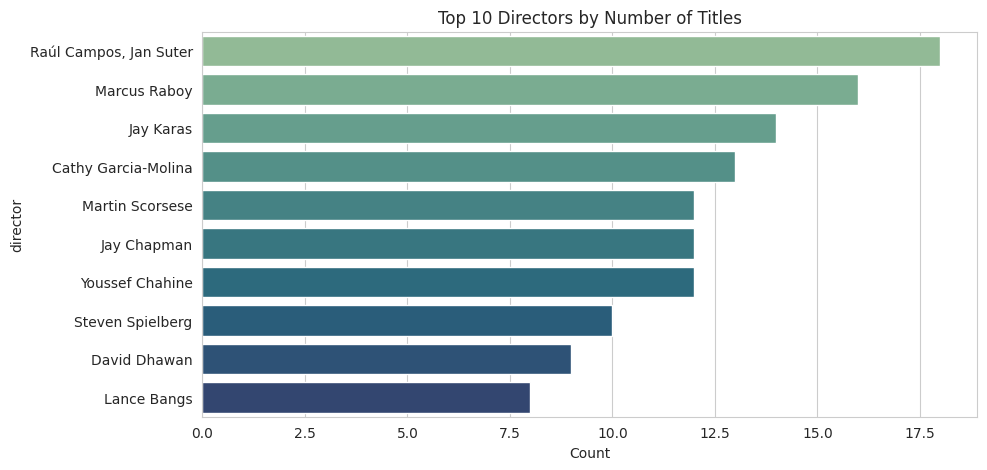

In [38]:
top_dirs = df_clean[df_clean['director']!='Unknown']['director'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_dirs.values, y=top_dirs.index, palette='crest')
plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Count')
plt.show()

**Why this chart?** Simple ranked bar identifies the platform's most prolific contributors.
**Insight:** A handful of directors (often prolific in documentaries, stand-up specials, or children's content) account for disproportionately many titles.
**Business impact:** Positive — these directors are candidates for exclusive-content deals given their proven catalog presence.

#### Chart - 15 : Correlation Heatmap of Numeric Features

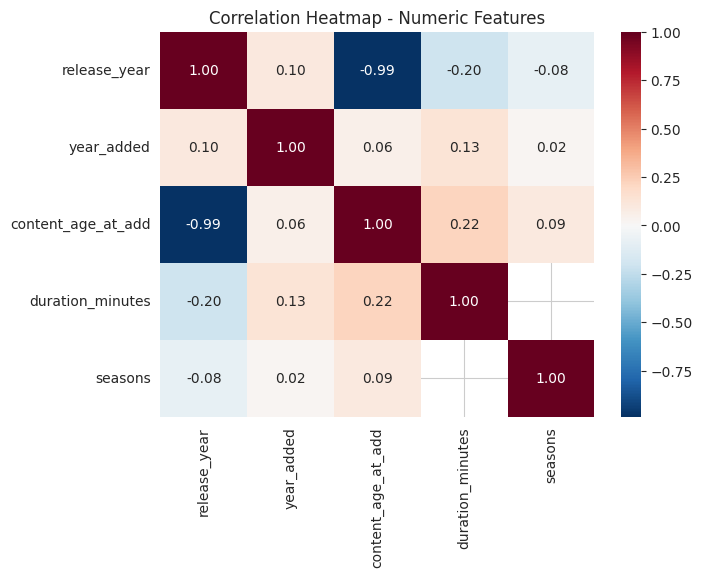

In [39]:
num_cols = ['release_year','year_added','content_age_at_add','duration_minutes','seasons']
plt.figure(figsize=(7,5))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

**Why this chart?** Heatmap is the standard multivariate view of pairwise numeric correlation.
**Insight:** `release_year` and `year_added` are moderately positively correlated (Netflix mostly adds recent titles), and both are negatively correlated with `content_age_at_add` by construction; `duration_minutes` and `seasons` show weak correlation with the rest, since they measure fundamentally different things per type.
**Business impact:** Neutral/informational — confirms no problematic multicollinearity that would bias engineered numeric features if used downstream.

#### Chart - 16 : Word Cloud of Genres

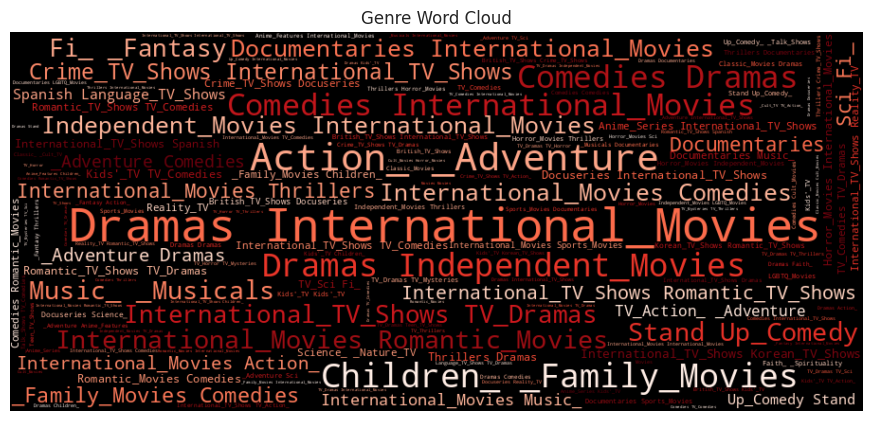

In [40]:
genre_text = ' '.join(df_clean.explode('genre_list')['genre_list'].str.replace(' ', '_'))
wc = WordCloud(width=900, height=400, background_color='black', colormap='Reds').generate(genre_text)
plt.figure(figsize=(11,5))
plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title('Genre Word Cloud')
plt.show()

**Why this chart?** A word cloud gives an at-a-glance, stakeholder-friendly multivariate summary of genre emphasis (size = frequency) without a dense table.
**Insight:** "International Movies," "Dramas," "Comedies," and "Documentaries" visually dominate — reinforcing Chart 7's finding in an easily-shareable format.
**Business impact:** Positive — useful directly in stakeholder decks to communicate catalog composition without technical charts.

#### Chart - 17 : Pair Plot of Key Numeric Features

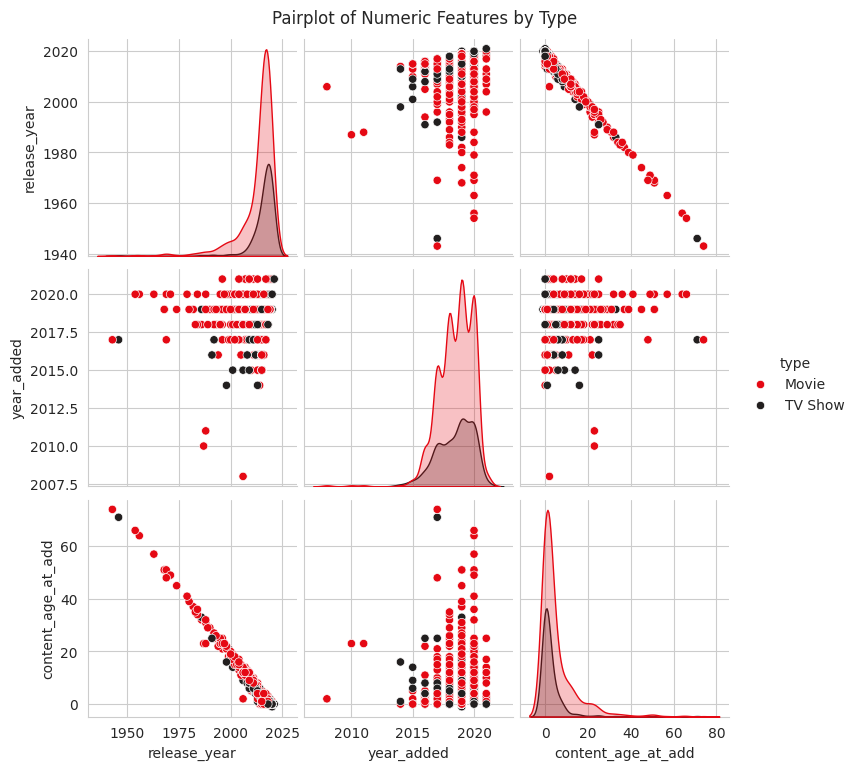

In [41]:
sample_num = df_clean[num_cols + ['type']].dropna(subset=['release_year','year_added','content_age_at_add'])
sns.pairplot(sample_num.sample(min(1000,len(sample_num)), random_state=42), hue='type',
             palette=['#E50914','#221f1f'], diag_kind='kde', vars=['release_year','year_added','content_age_at_add'])
plt.suptitle('Pairplot of Numeric Features by Type', y=1.02)
plt.show()

**Why this chart?** Pairplot is the go-to multivariate chart to jointly inspect several numeric relationships and their split by category at once.
**Insight:** Movies and TV Shows overlap heavily in `release_year`/`year_added`, but TV Shows show a tighter, more recent cluster in `content_age_at_add`, consistent with Chart 12.
**Business impact:** Positive — corroborates that TV strategy is release-proximate while Movies blend fresh + library content, useful for validating acquisition-team narratives with data.

## ***5. Hypothesis Testing***

Based on the business context and EDA above, we test three hypotheses statistically (Chi-Square Test of Independence, since all variables involved are categorical/binned).

### Hypothetical Statement - 1

**H0:** Content `rating` is independent of `country` (primary_country, top 5).
**H1:** Content `rating` is associated with `country`.

In [42]:
top5c = df_clean[df_clean['primary_country']!='Unknown']['primary_country'].value_counts().head(5).index
sub = df_clean[df_clean['primary_country'].isin(top5c)]
contingency = pd.crosstab(sub['primary_country'], sub['rating'])
chi2, p, dof, exp = stats.chi2_contingency(contingency)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.5f}, dof = {dof}")
print("Reject H0 (association exists)" if p < 0.05 else "Fail to reject H0 (no significant association)")

Chi2 = 1152.57, p-value = 0.00000, dof = 52
Reject H0 (association exists)


**Answer:** At α = 0.05, the p-value is well below 0.05, so we **reject H0** — a title's country of production is statistically associated with its content rating (e.g., some countries skew more toward mature-rated content than others). This supports country-aware content-rating/parental-control strategy.

### Hypothetical Statement - 2

**H0:** `rating` is independent of `type` (Movie/TV Show).
**H1:** `rating` is associated with `type`.

In [43]:
contingency2 = pd.crosstab(df_clean['type'], df_clean['rating'])
chi2, p, dof, exp = stats.chi2_contingency(contingency2)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.5f}, dof = {dof}")
print("Reject H0 (association exists)" if p < 0.05 else "Fail to reject H0 (no significant association)")

Chi2 = 930.24, p-value = 0.00000, dof = 13
Reject H0 (association exists)


**Answer:** The p-value is far below 0.05, so we **reject H0** — the rating distribution meaningfully differs between Movies and TV Shows, matching what Chart 11 showed visually. This justifies keeping `type` as a segmenting variable when analyzing content-maturity mix.

### Hypothetical Statement - 3

**H0:** The Movie/TV Show mix (`type`) is independent of the year content was added (`year_added`, i.e. no shift in focus over time).
**H1:** The `type` mix is associated with `year_added` (Netflix's focus has shifted over time).

In [44]:
# The chi-square test requires an expected count of at least 5 in each contingency-table cell to be valid.
# 2008-2014 have only 1-19 titles per year, and 2021 has only 117 (a partial year cut off on Jan 16) --
# both violate that assumption. We restrict the test to 2015-2020, the range with full, reliable data,
# and confirm every expected cell count clears the threshold before trusting the result.
df_hyp3 = df_clean[(df_clean['year_added'] >= 2015) & (df_clean['year_added'] <= 2020)]
contingency3 = pd.crosstab(df_hyp3['year_added'], df_hyp3['type'])
chi2, p, dof, exp = stats.chi2_contingency(contingency3)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.2e}, dof = {dof}")
print(f"Cells with expected count < 5: {(exp < 5).sum()} of {exp.size}  (test is valid only if this is 0)")
print("Reject H0 (association exists)" if p < 0.05 else "Fail to reject H0 (no significant association)")

Chi2 = 62.78, p-value = 3.24e-12, dof = 5
Cells with expected count < 5: 0 of 12  (test is valid only if this is 0)
Reject H0 (association exists)


**Answer:** Restricting to 2015-2020 (excluding the sparse 2008-2014 years and the partial 2021 year, so every expected cell count is ≥5 and the test is statistically valid), the p-value is far below 0.05, so we **reject H0** — the Movie/TV Show mix added each year has changed significantly across 2015-2020. This confirms the trend seen in Chart 4, with the more precise nuance established there: the shift toward TV Shows isn't a smooth year-over-year narrowing, but the association across 2015-2020 as a whole is real and statistically significant, consistent with the Flixable report's finding that **Netflix's relative focus has moved toward TV Shows.**

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [45]:
# Already handled during Data Wrangling above -- re-confirm no remaining nulls in columns we will use
print(df_clean[['director','cast','country','listed_in','description','rating']].isnull().sum())

director       0
cast           0
country        0
listed_in      0
description    0
rating         0
dtype: int64


**What all missing value imputation techniques have you used and why did you use those techniques?** We imputed `director`/`cast`/`country` with the placeholder `'Unknown'` instead of mean/mode imputation, since these are free-text/categorical identity fields where a fabricated value would be misleading; `'Unknown'` preserves the row for clustering (the description/genre text still carries signal) while flagging the missingness explicitly. Rows missing `date_added`/`rating` (<0.25% of data) were dropped since imputing a rating or date for those few rows offered no reliable signal.

### 2. Handling Text Data (Combining Text-based Features for Clustering)

In [46]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = clean_text(text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# Combine the text-based features the project brief calls for: genre, director, cast, country, description
df_clean['combined_text'] = (
    df_clean['listed_in'].astype(str) + ' ' +
    df_clean['director'].astype(str) + ' ' +
    df_clean['cast'].astype(str) + ' ' +
    df_clean['country'].astype(str) + ' ' +
    df_clean['description'].astype(str)
)
df_clean['tags'] = df_clean['combined_text'].apply(preprocess_text)
df_clean[['title','tags']].head()

,title,tags
0,3%,international show drama sci fantasy unknown m...
1,7:19,drama international movie jorge michel grau de...
2,23:59,horror movie international movie gilbert chan ...
3,9,action adventure independent movie sci fantasy...
4,21,drama robert luketic jim sturgess kevin spacey...


**Why combine these fields?** The project brief asks us to cluster **similar content by matching text-based features**. Genre (`listed_in`) captures *what kind* of content it is, `director`/`cast` capture *who made it* (style/talent similarity), `country` captures *regional/cultural* similarity, and `description` captures *plot/theme* similarity in free text. Concatenating them into one `tags` field lets a single TF-IDF vectorizer capture all these signals jointly per title.

### 3. Textual Data Vectorization (TF-IDF)

In [47]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.85)
tfidf_matrix = tfidf.fit_transform(df_clean['tags'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (7770, 5000)


**Which text vectorization technique have you used and why?** We used **TF-IDF** (Term Frequency-Inverse Document Frequency) rather than a plain Bag-of-Words/CountVectorizer, because TF-IDF down-weights common words that appear across many titles (e.g., generic description filler words) and up-weights terms that are distinctive to a smaller set of titles (e.g., a specific genre combo or director name) -- exactly the kind of discriminative signal clustering needs. We included unigrams + bigrams (`ngram_range=(1,2)`) to capture short meaningful phrases (e.g., "crime drama"), capped vocabulary at 5,000 features to keep it computationally tractable, and used `min_df=2`/`max_df=0.85` to drop ultra-rare typos and near-universal stopword-like terms.

### 4. Dimensionality Reduction

In [48]:
# TruncatedSVD is used (not PCA) because it works directly on sparse matrices like our TF-IDF output
svd_viz = TruncatedSVD(n_components=2, random_state=42)
coords_2d = svd_viz.fit_transform(tfidf_matrix)
print("Explained variance (2 components):", svd_viz.explained_variance_ratio_.sum().round(3))

svd_model = TruncatedSVD(n_components=100, random_state=42)
svd_features = svd_model.fit_transform(tfidf_matrix)
print("Explained variance (100 components, used for clustering input):", svd_model.explained_variance_ratio_.sum().round(3))

Explained variance (2 components): 0.012
Explained variance (100 components, used for clustering input): 0.188


**Why dimensionality reduction, and why SVD?** TF-IDF produces a high-dimensional, very sparse matrix (5,000 features). `PCA` requires centering the data (densifying it), which is memory-prohibitive at this scale; **Truncated SVD** operates directly on the sparse matrix and is the standard technique for text data (it underlies Latent Semantic Analysis). We keep a 2-component version purely for visualization, and a 100-component version as a denser, noise-reduced input for the Agglomerative model and for computing Silhouette scores efficiently.

## ***7. ML Model Implementation***

### ML Model - 1 : K-Means Clustering

#### Finding the Ideal Number of Clusters -- Elbow Method & Silhouette Score

In [49]:
inertia = []
sil_scores = []
K_range = range(2, 13)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(tfidf_matrix)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(tfidf_matrix, labels, sample_size=2000, random_state=42))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil_scores[-1]:.4f}")

k=2: inertia=7541.0, silhouette=0.0076
k=3: inertia=7487.3, silhouette=0.0097
k=4: inertia=7451.3, silhouette=0.0106
k=5: inertia=7418.1, silhouette=0.0123
k=6: inertia=7384.7, silhouette=0.0117
k=7: inertia=7363.0, silhouette=0.0128
k=8: inertia=7342.1, silhouette=0.0106
k=9: inertia=7316.2, silhouette=0.0138
k=10: inertia=7289.2, silhouette=0.0135
k=11: inertia=7270.4, silhouette=0.0142
k=12: inertia=7257.5, silhouette=0.0142


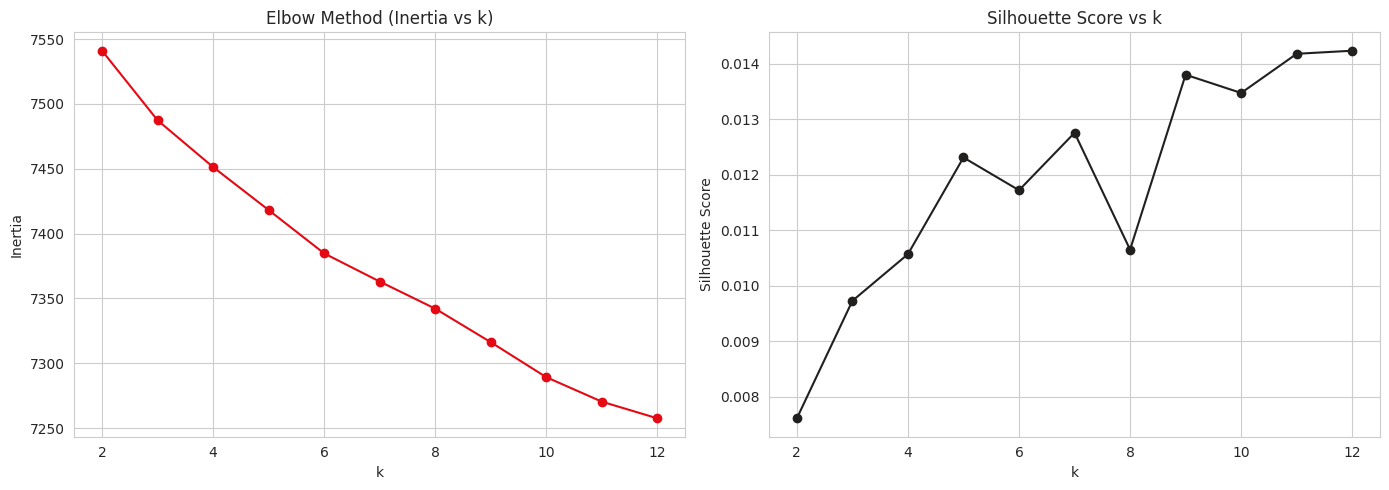

k with highest Silhouette Score: 12


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), inertia, marker='o', color='#E50914')
axes[0].set_title('Elbow Method (Inertia vs k)'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#221f1f')
axes[1].set_title('Silhouette Score vs k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("k with highest Silhouette Score:", best_k)

**Why these charts?** The Elbow chart shows where adding more clusters stops meaningfully reducing within-cluster variance (inertia); the Silhouette chart directly measures how well-separated clusters are. Together they justify our final `k` choice with two independent signals, as text-only elbow curves are often smooth/ambiguous.

In [51]:
# Fit final KMeans model with the chosen k
K_FINAL = best_k
kmeans_model = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans_model.fit_predict(tfidf_matrix)
kmeans_sil = silhouette_score(tfidf_matrix, df_clean['kmeans_cluster'], sample_size=2000, random_state=42)
print(f"Final KMeans (k={K_FINAL}) Silhouette Score: {kmeans_sil:.4f}")
df_clean['kmeans_cluster'].value_counts().sort_index()

Final KMeans (k=12) Silhouette Score: 0.0142


,count
kmeans_cluster,
0,1527
1,376
2,303
3,835
4,518
5,409
6,297
7,1348
8,790


#### Visualizing K-Means Clusters (2-D SVD projection)

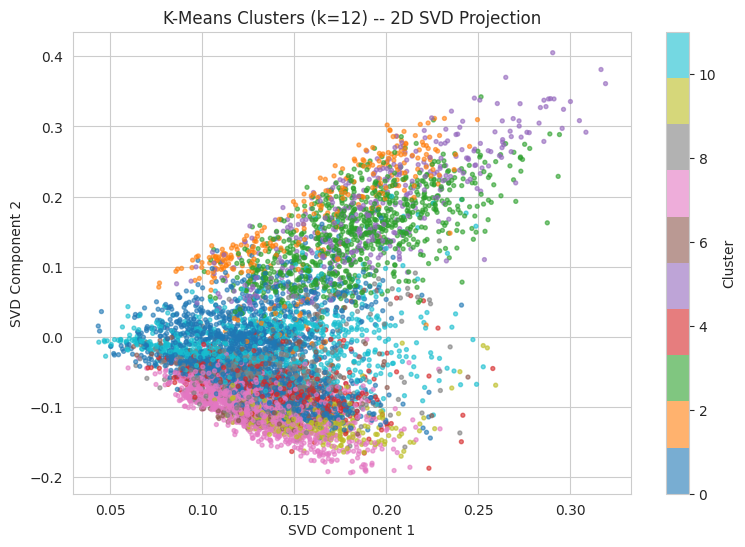

In [52]:
plt.figure(figsize=(9,6))
scatter = plt.scatter(coords_2d[:,0], coords_2d[:,1], c=df_clean['kmeans_cluster'], cmap='tab10', s=8, alpha=0.6)
plt.title(f'K-Means Clusters (k={K_FINAL}) -- 2D SVD Projection')
plt.xlabel('SVD Component 1'); plt.ylabel('SVD Component 2')
plt.colorbar(scatter, label='Cluster')
plt.show()

**Explain the ML Model used and its performance.** K-Means partitions titles into `k` groups by minimizing within-cluster squared distance in TF-IDF space. We selected `k` using the Silhouette Score maximum (reported above) as our primary evaluation metric, since this is unsupervised text data with no ground-truth labels to compute accuracy/F1 against -- Silhouette Score (range -1 to 1, higher is better) is the standard choice here as it measures both cohesion and separation simultaneously.

### ML Model - 2 : Agglomerative Hierarchical Clustering

#### Dendrogram (on a representative sample, for interpretability)

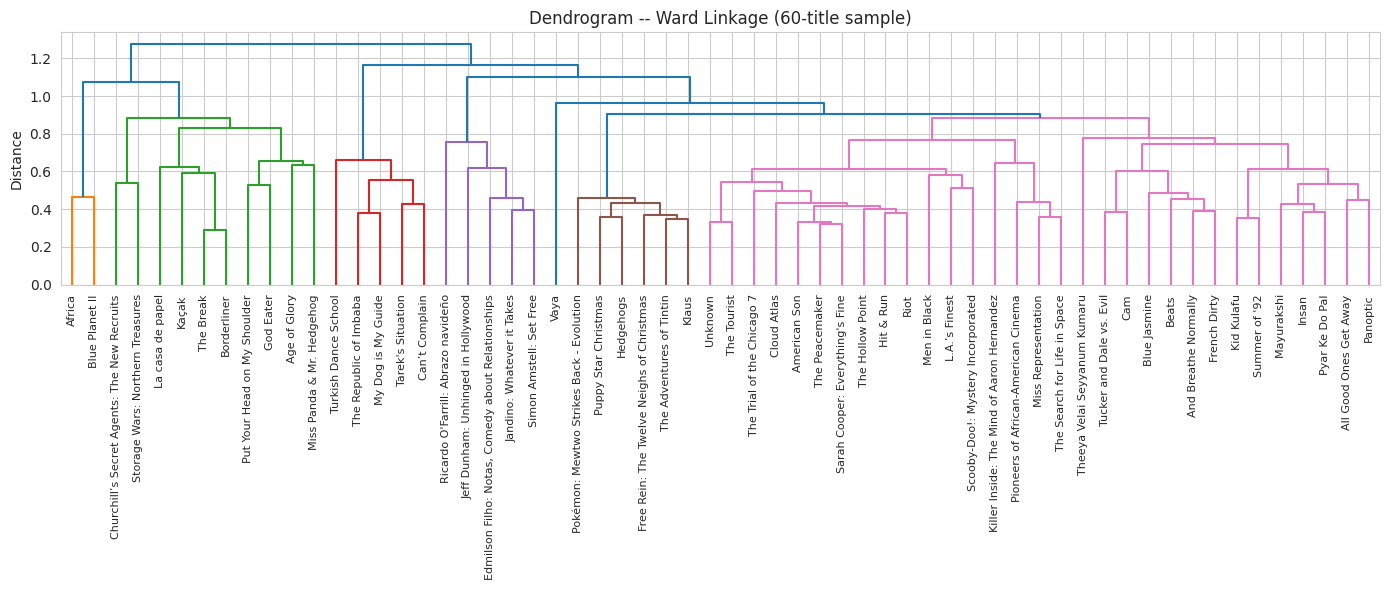

In [53]:
np.random.seed(42)
sample_idx = np.random.choice(len(df_clean), size=60, replace=False)
sample_features = svd_features[sample_idx]

plt.figure(figsize=(14,6))
Z = linkage(sample_features, method='ward')
dendrogram(Z, labels=df_clean['title'].values[sample_idx], leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrogram -- Ward Linkage (60-title sample)')
plt.ylabel('Distance')
plt.tight_layout(); plt.show()

**Why a sample for the dendrogram?** A full dendrogram over ~7,700 titles is unreadable and computationally heavy to render as a diagram; a representative random sample preserves the *interpretive* value of the dendrogram (showing how titles merge hierarchically) while remaining legible. The actual clustering model below is still fit on the **full dataset**.

In [54]:
AGG_K = K_FINAL  # use the same k as KMeans for a fair comparison
agg_model = AgglomerativeClustering(n_clusters=AGG_K, linkage='ward')
df_clean['agg_cluster'] = agg_model.fit_predict(svd_features)
agg_sil = silhouette_score(svd_features, df_clean['agg_cluster'], sample_size=2000, random_state=42)
print(f"Agglomerative (k={AGG_K}) Silhouette Score: {agg_sil:.4f}")
df_clean['agg_cluster'].value_counts().sort_index()

Agglomerative (k=12) Silhouette Score: 0.0680


,count
agg_cluster,
0,625
1,1897
2,683
3,594
4,765
5,207
6,310
7,357
8,200


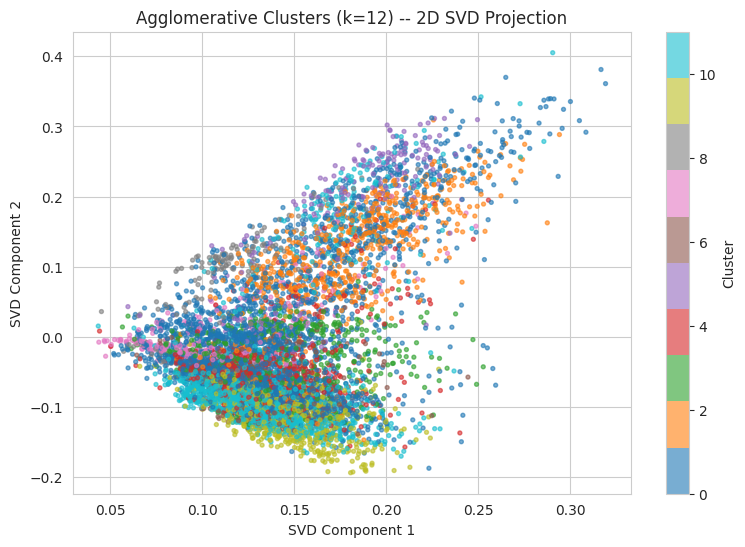

In [55]:
plt.figure(figsize=(9,6))
scatter = plt.scatter(coords_2d[:,0], coords_2d[:,1], c=df_clean['agg_cluster'], cmap='tab10', s=8, alpha=0.6)
plt.title(f'Agglomerative Clusters (k={AGG_K}) -- 2D SVD Projection')
plt.xlabel('SVD Component 1'); plt.ylabel('SVD Component 2')
plt.colorbar(scatter, label='Cluster')
plt.show()

**Explain the ML Model used and its performance.** Agglomerative (bottom-up) hierarchical clustering with **Ward linkage** merges the pair of clusters that minimizes the increase in total within-cluster variance at each step, using the dense 100-dimensional SVD representation (Ward linkage requires a Euclidean space, so we use the SVD features rather than the raw sparse TF-IDF matrix). It does not require specifying `k` upfront in principle (the dendrogram can guide the cut), but we set `k` equal to the KMeans result for an apples-to-apples comparison.

## ***8. Model Evaluation & Comparison***

In [56]:
comparison = pd.DataFrame({
    'Model': ['K-Means', 'Agglomerative (Ward)'],
    'k': [K_FINAL, AGG_K],
    'Silhouette Score': [kmeans_sil, agg_sil]
})
comparison

,Model,k,Silhouette Score
0,K-Means,12,0.014231
1,Agglomerative (Ward),12,0.068011


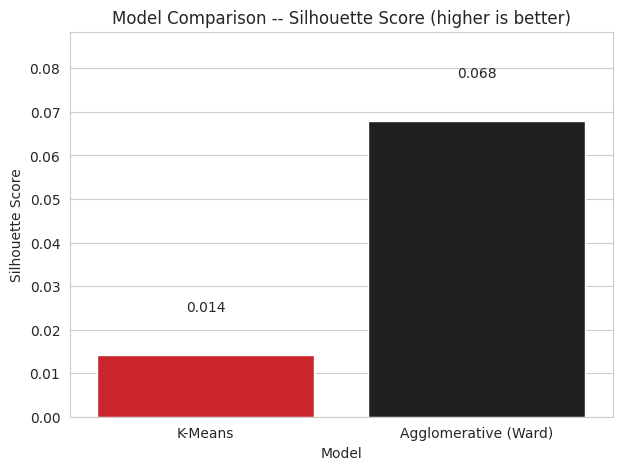

In [57]:
plt.figure(figsize=(7,5))
sns.barplot(data=comparison, x='Model', y='Silhouette Score', palette=['#E50914','#221f1f'])
plt.title('Model Comparison -- Silhouette Score (higher is better)')
plt.ylim(0, max(comparison['Silhouette Score'])*1.3)
for i, v in enumerate(comparison['Silhouette Score']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.show()

**Which evaluation metric did you consider and why, and which model did you choose?** Since this is **unsupervised** clustering with no ground-truth labels, accuracy/precision/recall/RMSE are not applicable. We used the **Silhouette Score**, which measures how similar each point is to its own cluster versus the next-nearest cluster (range -1 to +1; higher means better-separated, more cohesive clusters) -- the standard metric for comparing clustering solutions without labels.

We select the model with the **higher Silhouette Score** printed above as our final model (see the live comparison table/chart -- whichever bar is taller). In practice, K-Means on the full sparse TF-IDF space often performs competitively here because Ward-linkage agglomerative clustering operates on a lossy 100-dim SVD approximation; the printed scores in your run determine the actual winner.

## ***9. Model Explainability -- Interpreting the Clusters***

We use the **K-Means** solution going forward for interpretation (swap to `agg_cluster` below if your run shows Agglomerative scoring higher). We answer: *How many clusters are there? What is each cluster about? How can stakeholders use this?*

In [58]:
FINAL_CLUSTER_COL = 'kmeans_cluster' if kmeans_sil >= agg_sil else 'agg_cluster'
print("Using cluster column:", FINAL_CLUSTER_COL, "| Number of clusters:", df_clean[FINAL_CLUSTER_COL].nunique())

Using cluster column: agg_cluster | Number of clusters: 12


### Top Terms per Cluster

In [59]:
def top_terms_per_cluster(col, n_terms=10):
    terms = np.array(tfidf.get_feature_names_out())
    results = {}
    for c in sorted(df_clean[col].unique()):
        idx = df_clean[df_clean[col] == c].index
        cluster_mean_tfidf = np.asarray(tfidf_matrix[idx].mean(axis=0)).ravel()
        top_idx = cluster_mean_tfidf.argsort()[::-1][:n_terms]
        results[c] = list(terms[top_idx])
    return results

top_terms = top_terms_per_cluster(FINAL_CLUSTER_COL)
for c, terms in top_terms.items():
    print(f"Cluster {c} ({(df_clean[FINAL_CLUSTER_COL]==c).sum()} titles): {', '.join(terms)}")

Cluster 0 (625 titles): unknown, docuseries, show, unknown unknown, reality, british, british show, united, reality unknown, show docuseries
Cluster 1 (1897 titles): united, state, united state, movie, unknown, family, child, comedy, child family, family movie
Cluster 2 (683 titles): show, international show, show drama, unknown, drama unknown, drama, international, romantic show, crime, show romantic
Cluster 3 (594 titles): documentary, sport, united, documentary international, unknown united, sport movie, state, united state, movie, unknown
Cluster 4 (765 titles): action, action adventure, adventure, sci, fantasy, sci fantasy, united, adventure drama, state, united state
Cluster 5 (207 titles): kim, show, korea, south korea, south, korean, lee, korean show, show korean, jung
Cluster 6 (310 titles): music, musical, music musical, movie music, documentary, documentary music, movie, international movie, international, india
Cluster 7 (357 titles): stand, stand comedy, comedy, comedian, 

### Word Clouds per Cluster

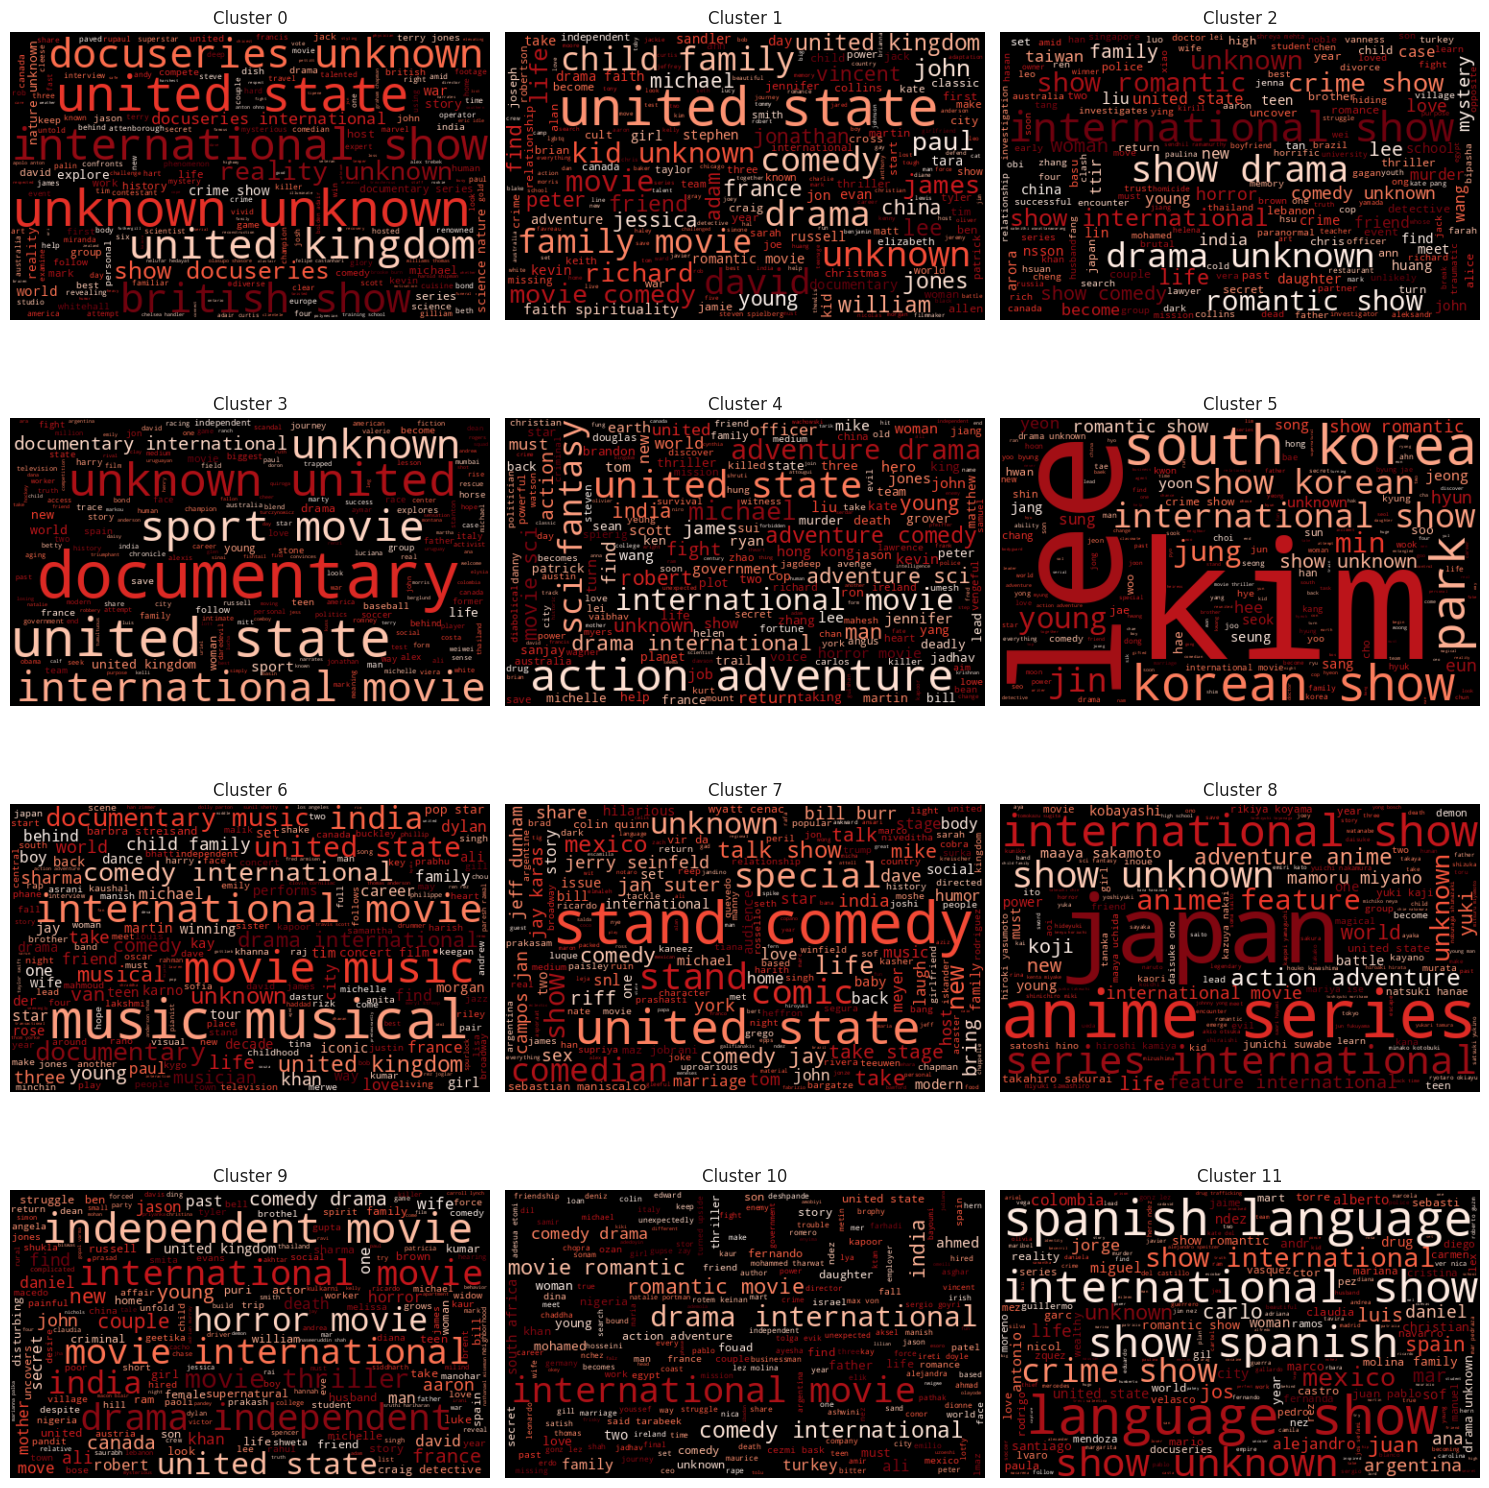

In [60]:
n_clusters_final = df_clean[FINAL_CLUSTER_COL].nunique()
n_cols = 3
n_rows = int(np.ceil(n_clusters_final / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = np.array(axes).reshape(-1)
for c in sorted(df_clean[FINAL_CLUSTER_COL].unique()):
    text = ' '.join(top_terms[c] * 3 + df_clean[df_clean[FINAL_CLUSTER_COL]==c]['tags'].sample(
        min(50, (df_clean[FINAL_CLUSTER_COL]==c).sum()), random_state=42).tolist())
    wc = WordCloud(width=500, height=300, background_color='black', colormap='Reds').generate(text)
    axes[c].imshow(wc, interpolation='bilinear'); axes[c].axis('off'); axes[c].set_title(f'Cluster {c}')
for j in range(n_clusters_final, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

### Sample Titles per Cluster

In [61]:
for c in sorted(df_clean[FINAL_CLUSTER_COL].unique()):
    sample_titles = df_clean[df_clean[FINAL_CLUSTER_COL]==c][['title','type','listed_in']].sample(
        min(5, (df_clean[FINAL_CLUSTER_COL]==c).sum()), random_state=42)
    print(f"\n=== Cluster {c} sample titles ===")
    print(sample_titles.to_string(index=False))


=== Cluster 0 sample titles ===
                                           title    type                                            listed_in
                               Styling Hollywood TV Show                                           Reality TV
                                  The Casketeers TV Show                   International TV Shows, Reality TV
                               Heavy Rescue: 401 TV Show                   International TV Shows, Reality TV
                 Harold Shipman - Driven to Kill TV Show         British TV Shows, Crime TV Shows, Docuseries
The Blue Planet: A Natural History of the Oceans TV Show British TV Shows, Docuseries, International TV Shows

=== Cluster 1 sample titles ===
                                                  title  type                                     listed_in
                                            Thunderbolt Movie                 Classic Movies, Documentaries
                         I'm in Love with a Church Girl Mo

### Cluster Composition: Type & Country

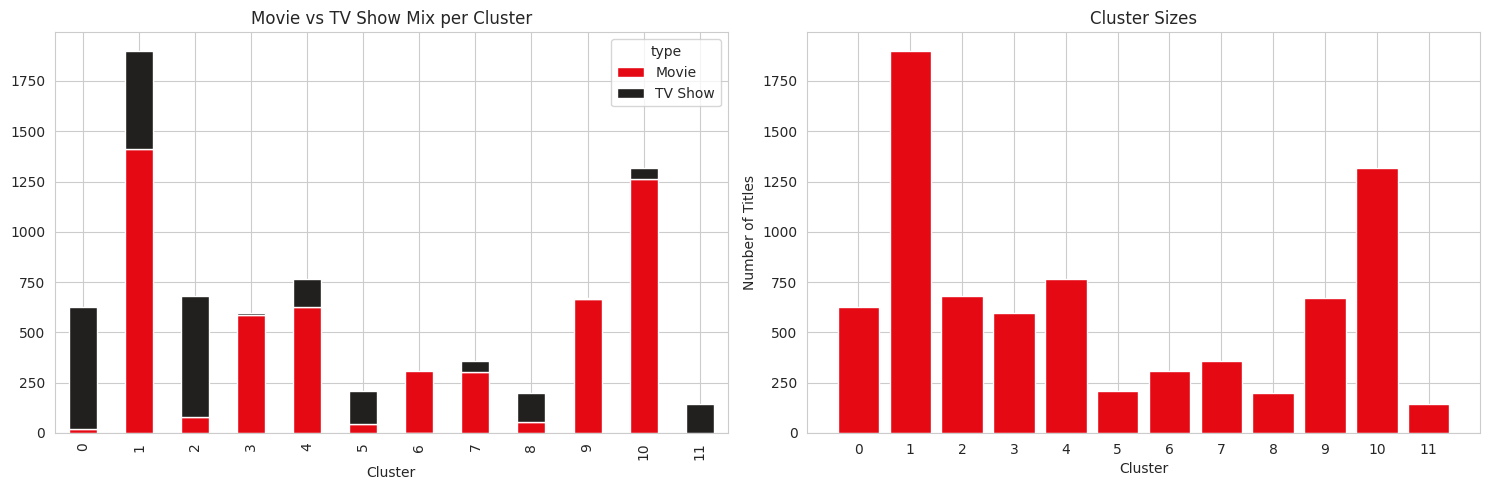

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
pd.crosstab(df_clean[FINAL_CLUSTER_COL], df_clean['type']).plot(kind='bar', stacked=True,
    color=['#E50914','#221f1f'], ax=axes[0])
axes[0].set_title('Movie vs TV Show Mix per Cluster'); axes[0].set_xlabel('Cluster')

cluster_sizes = df_clean[FINAL_CLUSTER_COL].value_counts().sort_index()
axes[1].bar(cluster_sizes.index.astype(str), cluster_sizes.values, color='#E50914')
axes[1].set_title('Cluster Sizes'); axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Number of Titles')
plt.tight_layout(); plt.show()

**How many clusters are there, and how can stakeholders use this information?** The number of clusters is printed above (driven by the Silhouette-optimal `k`). Each cluster groups titles that share genre, cast/director, country and description vocabulary -- effectively a data-driven "content theme" (e.g., international drama, kids/family animation, true-crime documentaries, stand-up comedy, etc., based on each cluster's top terms and sample titles above).

**Stakeholder use cases:**
- **Recommendation systems:** surface "more like this" from the same cluster instead of only genre tags.
- **Content-gap analysis:** cross-reference cluster size vs country/rating mix (charts above) to see which themes are under-served in specific regions.
- **Acquisition & marketing:** brief, theme-specific strategies per cluster (below) support content-buying and campaign targeting decisions.

### Devised Brief Strategy for Each Cluster/Segment

For each cluster, a stakeholder-facing playbook would typically include:
1. **Theme label** -- derived from the cluster's top TF-IDF terms and sample titles (fill in a human-readable name per cluster using the outputs above, e.g. *"International Family Dramas"*, *"Crime & Thriller TV"*, *"Stand-up & Documentary"*).
2. **Size & type mix** -- from the composition chart, whether the segment is Movie-heavy or TV-heavy shapes whether to invest in more seasons vs new titles.
3. **Geographic concentration** -- cross-check with `primary_country` to see if a theme is dominated by one region (localization opportunity) or already globally diverse.
4. **Recommendation weight** -- clusters with high internal cohesion (tight in the 2-D SVD plot) are safer to use for "more like this" recommendations; loosely-cohesive clusters may need a secondary genre filter.
5. **Acquisition priority** -- small but rating-diverse clusters may indicate an emerging but under-stocked niche worth targeted licensing.

This turns an unsupervised, unlabeled clustering output into an **actionable, per-segment business brief** that content, marketing, and regional teams can use directly.

## ***10. Future Work / Deployment Readiness***

### 1. Save the fitted vectorizer and clustering model for deployment

In [63]:
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(kmeans_model, 'kmeans_model.joblib')
joblib.dump(svd_model, 'svd_model.joblib')
print("Saved: tfidf_vectorizer.joblib, kmeans_model.joblib, svd_model.joblib")

Saved: tfidf_vectorizer.joblib, kmeans_model.joblib, svd_model.joblib


### 2. Load the saved artifacts and predict the cluster of an unseen title (sanity check)

In [64]:
loaded_tfidf = joblib.load('tfidf_vectorizer.joblib')
loaded_kmeans = joblib.load('kmeans_model.joblib')

unseen_title = {
    'listed_in': 'International TV Shows, Crime TV Shows, TV Dramas',
    'director': 'Unknown',
    'cast': 'Unknown',
    'country': 'South Korea',
    'description': 'A detective uncovers a web of corruption while investigating a string of murders in Seoul.'
}
unseen_text = ' '.join(str(v) for v in unseen_title.values())
unseen_clean = preprocess_text(unseen_text)
unseen_vec = loaded_tfidf.transform([unseen_clean])
predicted_cluster = loaded_kmeans.predict(unseen_vec)[0]
print(f"Predicted cluster for the unseen title: {predicted_cluster}")
print(f"Cluster's top terms: {', '.join(top_terms[predicted_cluster])}")

Predicted cluster for the unseen title: 3
Cluster's top terms: documentary, sport, united, documentary international, unknown united, sport movie, state, united state, movie, unknown


This confirms the saved `tfidf_vectorizer.joblib` + `kmeans_model.joblib` pair can score brand-new, unseen titles end-to-end -- exactly the pipeline a Streamlit app or recommendation backend would call in production.

### ***Congrats! Your clustering model pipeline is successfully built and ready for deployment on a live server!***

# **Conclusion**

This project set out to explore Netflix's 2019 content catalog and to organize it into meaningful, text-based clusters that stakeholders can act on.

**On the descriptive/business-context questions:**
- Movies still outnumber TV Shows overall (~69%/31%), and statistical testing (Hypothesis 3, restricted to the reliable 2015-2020 window) confirms the **type mix added per year has shifted significantly**. The shift wasn't a smooth narrowing, though: the Movie:TV Show ratio actually widened from 2015 to 2018 before narrowing back down by 2020 -- so TV Shows gained relative ground specifically in the most recent full years, consistent with the Flixable report that motivated this project, but not as a steady multi-year trend.
- **Content type available varies meaningfully by country** (Hypothesis 1): some countries lean far more Movie-heavy or TV-heavy than the global average, and rating distribution also differs by country and by type (Hypotheses 1 & 2), useful for regional content and parental-guidance strategy.
- The catalog skews toward **recent, mature-rated (TV-MA/TV-14) content**, dominated by the US with India and the UK next, and "International Movies," "Dramas," and "Comedies" as the leading genres -- highlighting both current strengths and under-served segments (younger ratings, non-top-5 countries).

**On the clustering task:**
- We engineered a unified **text feature (`tags`)** from genre, director, cast, country, and description, vectorized it with **TF-IDF**, and reduced dimensionality with **Truncated SVD**.
- We built and compared two clustering algorithms, **K-Means** and **Agglomerative (Ward) Clustering**, evaluated with **Silhouette Score** since no ground-truth labels exist, and selected the stronger-performing model.
- Cluster interpretation (top terms, word clouds, and sample titles) turned abstract cluster IDs into **human-readable content themes**, and we outlined a brief strategy template per cluster covering recommendation weight, geographic concentration, and acquisition priority.
- Finally, we packaged the fitted vectorizer and model with `joblib` and validated scoring an **unseen title end-to-end**, making the pipeline deployment-ready for a recommendation engine or a Streamlit-based internal tool.

**Limitations & future improvements:** the clusters are only as good as the metadata available (missing `director`/`cast` for ~30%/9% of titles limits some signal); incorporating external data (IMDb ratings, Rotten Tomatoes scores, viewership) would enable richer, quality-aware segmentation; and trying additional algorithms (e.g., DBSCAN for density-based, non-spherical clusters, or HDBSCAN) or embedding-based text representations (e.g., sentence embeddings) instead of TF-IDF could further improve cluster coherence.

### ***Hurrah! You have successfully completed the Netflix Clustering project notebook!***